# Notebook 03: Traffic & Carbon Baseline Analysis

**Purpose:** Establish baseline traffic and environmental metrics for the unmodified SUMO scenario (using standard SUMO-controlled traffic light policies).

We compute:
- Total CO2 emissions
- Average CO2 per vehicle
- Total waiting time
- Average waiting time per vehicle
- Average speed
- Traffic throughput
- NOx and Fuel consumption


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

features_path = Path("../data/processed/rl_features.csv")
raw_path = Path("../data/raw/simulation_data.csv")


### Load Features & Compute Global Metrics

In [2]:
df_feat = pd.read_csv(features_path)
df_raw = pd.read_csv(raw_path, skiprows=lambda i: i > 0 and i % 10 != 0)

# Calculate global statistics
# Scale total emissions back up from the 10x raw sample
total_co2_kg = (df_raw["co2"].sum() * 10) / 1e6 # mg to kg
total_nox_g = (df_raw["nox"].sum() * 10) / 1e3  # mg to g
total_fuel_l = (df_raw["fuel_consumption"].sum() * 10) / 1e6 # ml to liters (approx)
total_waiting_time_hrs = (df_raw["waiting_time"].sum() * 10) / 3600.0

avg_waiting_time_s = df_raw["waiting_time"].mean()
avg_speed_kmh = df_raw["speed"].mean() * 3.6
avg_co2_mg = df_raw["co2"].mean()

print(f"Total CO2: {total_co2_kg:.2f} kg")
print(f"Total NOx: {total_nox_g:.2f} g")
print(f"Total Waiting Time: {total_waiting_time_hrs:.2f} hours")
print(f"Average Waiting Time per Vehicle-step: {avg_waiting_time_s:.2f} s")
print(f"Average Speed: {avg_speed_kmh:.2f} km/h")


Total CO2: 20383.67 kg
Total NOx: 7545.50 g
Total Waiting Time: 3140.21 hours
Average Waiting Time per Vehicle-step: 1.44 s
Average Speed: 41.54 km/h


### Save Baseline Metrics JSON

In [3]:
baseline_metrics = {
    "total_co2_kg": float(total_co2_kg),
    "total_nox_g": float(total_nox_g),
    "total_fuel_l": float(total_fuel_l),
    "total_waiting_time_hrs": float(total_waiting_time_hrs),
    "avg_waiting_time_s": float(avg_waiting_time_s),
    "avg_speed_kmh": float(avg_speed_kmh),
    "avg_co2_mg": float(avg_co2_mg)
}

metrics_path = Path("../reports/baseline_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(baseline_metrics, f, indent=4)
print(f"Saved baseline metrics to: {metrics_path}")


Saved baseline metrics to: ..\reports\baseline_metrics.json


### Visualize Baseline Trends

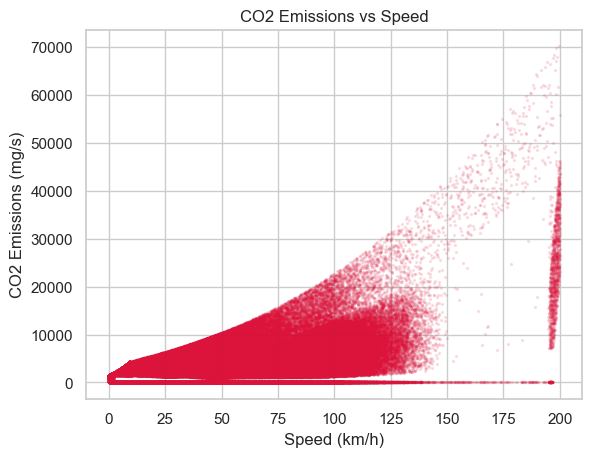

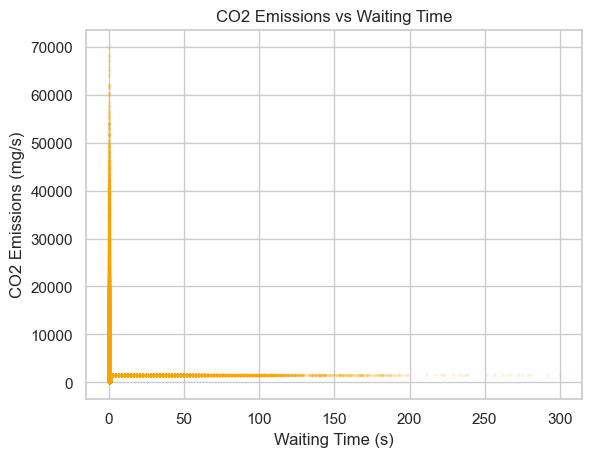

In [4]:
# CO2 vs Speed Scatter
plt.figure()
plt.scatter(df_raw["speed"] * 3.6, df_raw["co2"], alpha=0.1, color="crimson", s=2)
plt.title("CO2 Emissions vs Speed")
plt.xlabel("Speed (km/h)")
plt.ylabel("CO2 Emissions (mg/s)")
plt.savefig("../reports/figures/co2_vs_speed.png", dpi=300)
plt.show()

# CO2 vs Waiting Time
plt.figure()
plt.scatter(df_raw["waiting_time"], df_raw["co2"], alpha=0.1, color="orange", s=2)
plt.title("CO2 Emissions vs Waiting Time")
plt.xlabel("Waiting Time (s)")
plt.ylabel("CO2 Emissions (mg/s)")
plt.savefig("../reports/figures/co2_vs_waiting_time.png", dpi=300)
plt.show()
